<h1><center>Subspace Identification: Upstream Oil and Gas Process</center></h1>

![PFD](upstream_pfd.jpg)

There are three wells feeding the three-phase high-pressure separator. The separator separates the feed into three products; water, oil, and gas. The off-gas is sent to a flash drum and separated again into the gas export and bottoms oil stream, which is mixed with the oil stream from the high-pressure separator.

This mixture enters the low-pressure separator, which also has three products; water, oil, and gas. The water leaving the low-pressure separator is mixed with the water from the high-pressure separator and sent to a de-gasser to remove any gas and discard the water.

The off-gas from the low-pressure separator is sent to a second flash drum and separated again into a recycle stream that is mixed with the off-gas from the high-pressure separator and a bottoms oil stream, which is mixed with the oil stream from the low-pressure separator to become the oil export.

In [1]:
import numpy as np
import pandas as pd
from scipy import signal, stats, fftpack
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.dirname(os.getcwd()))
from sysidbox.subspace import system_identification
from sysidbox.functionsetSIM import get_model_uncertainty, get_deadtime, get_fir_coef, get_step_response
from harold import simulate_step_response, simulate_impulse_response, undiscretize, discretize
from detrend.detrending_filter import DetrendingFilter
# %matplotlib widget

In [2]:
# Load spteptest data from a TSV file
file = os.path.join(os.path.dirname(os.getcwd()),'data','Upstream-HP.txt')
hp_columns = ['Time', 'KOPC_OP',  'KOPC_SP',  'PIC100X_OP',  'PIC100X_SP', 'TIC100_OP', 'TIC100_SP', 'GAS.PV', 'HPCPOWER.PV', 'WELL1.OP', 'WELL2.OP', 'WELL3.OP']
lp_columns = ['Time', 'LIC102_OP', 'PIC100_OP', 'PIC100X_SP','PIC1042_OP', 'PIC1042_SP', 'TIC101_OP', 'TIC101_SP',  'TIC104_OP', 'TIC104_SP', 'MPC1POWER.PV', 'MPC2POWER.PV']
lwvwl_columns = ['Time', 'LIC102', 'LIC102_OP', 'LIC106', 'LIC106_OP', 'LIC110', 'LIC110_OP', 'PIC1042_SP', 'TIC101_SP', 'TIC104_SP', 'WELL1.OP', 'WELL2.OP', 'WELL3.OP']
step_test_data = pd.read_csv(file,skiprows=[1,2], usecols=hp_columns, sep='\t')
step_test_data['Time'] = pd.to_datetime(step_test_data['Time'])
step_test_data = step_test_data.set_index('Time').asfreq('1Min')

In [3]:
step_test_data.describe()

,KOPC_OP,KOPC_SP,PIC100X_OP,PIC100X_SP,TIC100_OP,TIC100_SP,GAS.PV,HPCPOWER.PV,WELL1.OP,WELL2.OP,WELL3.OP
count,37915.000000,37915.000000,37915.000000,37915.000000,37915.000000,37915.000000,37915.000000,37915.000000,37915.000000,37915.000000,37915.000000
mean,69.981961,2699.733920,71.347245,2853.675586,18.111600,22.378844,139.995346,2969.774707,74.872335,71.450713,76.752450
std,6.915131,28.058101,8.790828,36.568249,0.875423,1.450484,6.333881,55.868992,6.032860,7.602969,5.928531
min,48.210800,2641.190000,49.311000,2800.000000,14.734300,19.498400,114.901000,2709.100000,54.146800,50.000000,56.195400
25%,65.795250,2685.540000,65.150100,2818.480000,17.603300,21.788900,136.576000,2940.475000,70.784500,66.810700,74.573300
50%,70.599400,2702.000000,70.801200,2855.490000,18.169000,22.498400,141.726000,2983.590000,75.078800,71.710700,77.865300
75%,75.162300,2717.520000,77.243100,2889.880000,18.740700,23.888900,145.102500,3007.890000,79.515800,77.486900,80.933600
max,87.965400,2776.590000,100.000000,2900.000000,20.369100,24.038900,153.519000,3098.020000,85.000000,85.000000,85.000000


In [4]:
badslice1_start = step_test_data.index.get_loc('07-18-2016 19:00:00')
badslice1_end = step_test_data.index.get_loc('07-18-2016 21:00:00')

array([<AxesSubplot:xlabel='Time'>, <AxesSubplot:xlabel='Time'>,
       <AxesSubplot:xlabel='Time'>, <AxesSubplot:xlabel='Time'>,
       <AxesSubplot:xlabel='Time'>, <AxesSubplot:xlabel='Time'>,
       <AxesSubplot:xlabel='Time'>, <AxesSubplot:xlabel='Time'>,
       <AxesSubplot:xlabel='Time'>, <AxesSubplot:xlabel='Time'>,
       <AxesSubplot:xlabel='Time'>], dtype=object)

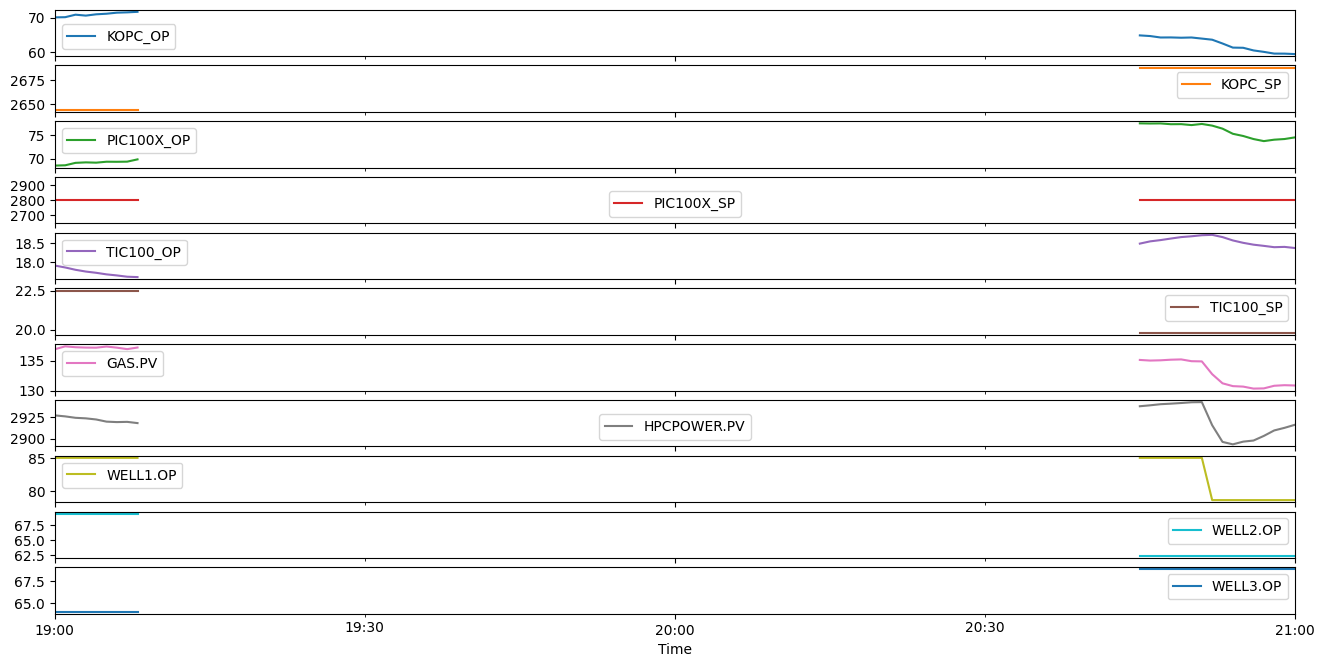

In [6]:
plt.rcParams['figure.figsize'] = [16, 8]
plt.rcParams['figure.dpi'] = 100
tags_to_plot = ['KOPC_OP',  'KOPC_SP',  'PIC100X_OP',  'PIC100X_SP', 'TIC100_OP', 'TIC100_SP', 'GAS.PV', 'HPCPOWER.PV', 'WELL1.OP', 'WELL2.OP', 'WELL3.OP']#['KOPC_OP',  'KOPC_SP', 'PIC100X_OP',  'PIC100X_SP', 'TIC100_OP', 'TIC100_SP', 'GAS.PV', 'HPCPOWER.PV', 'WELL1.OP', 'WELL2.OP', 'WELL3.OP']
step_test_data[tags_to_plot].loc['07-18-2016 19:00':'07-18-2016 21:00'].plot(subplots=True)

In [7]:
inputs = ['WELL1.OP', 'WELL2.OP', 'WELL3.OP', 'KOPC_SP', 'PIC100X_SP', 'TIC100_SP']
outputs = ['PIC100X_OP', 'KOPC_OP', 'TIC100_OP', 'HPCPOWER.PV', 'GAS.PV']

In [9]:
#slice data for model identification case
slices ={"slice1":{"type":"bad", "isGlobal": True, "start":badslice1_start, "end":badslice1_end, "Description": "OPC bad for AI-2020","tags":[]}}

In [10]:
#specify model identification parameters, reffer the documentation for detais.
tss = 90                   # Process time to steady state
controller_sampling = 1    # Controller sampling time
filter_tss_mult_factor = 3 # 3 for self-regulating CV, 6 for ramp CV
resampling = 1             # For tss more than 90 use 2, and if grater than 240 use 3 
id_method='CVA'            # CVA, MOESP, N4SID
IC = 'AIC'                 # None, AIC, AICc, BIC
TH =  20                   # The length of time horizon used for regression
fix_ordr = 12              # Used if and only if IC = 'None'
ss_orders = [1, 20]        # SS orser min and max, Used if IC = AIC, AICc or BIC
SS_threshold = 0.2         # Singular value threshold
req_D = True
force_A_stable = False

In [11]:
# Create FIR filter to detrend signal 
tags = inputs + outputs
filter_type  = 'highpass' # Valid filters ['highpass', 'difference', 'doubledifference', 'zeromean', 'none']
d_filter = DetrendingFilter().get_filter(filter_type)
if filter_type == 'highpass':
    d_filter.apply_filter(step_test_data[tags], tss, filter_tss_mult_factor, slices)
else:
    d_filter.apply_filter(step_test_data[tags], slices)
    
idinput = d_filter.filterdata.data["output"]

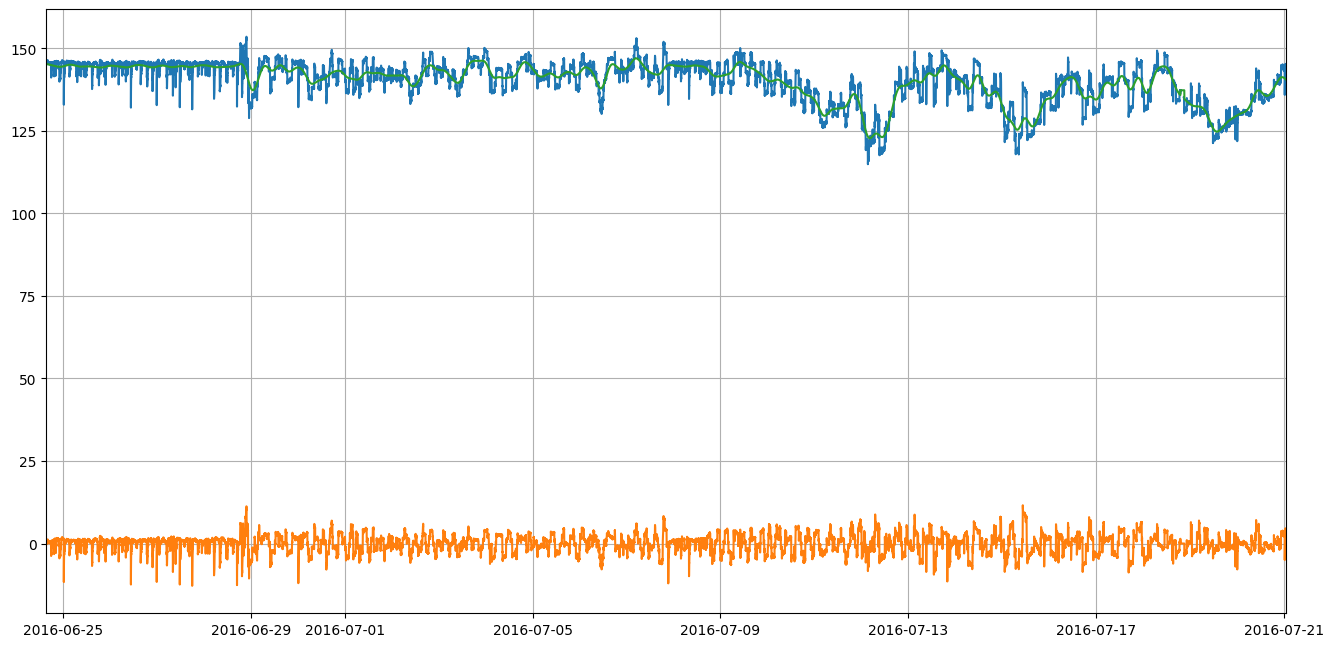

In [12]:
tag = 'GAS.PV'
trend = d_filter.filterdata.data["trend"]
plt.plot(step_test_data.index, step_test_data[tag], idinput.index, idinput[tag], trend.index, trend[tag])
plt.margins(x=0)
plt.grid()

array([<AxesSubplot:xlabel='Time'>, <AxesSubplot:xlabel='Time'>,
       <AxesSubplot:xlabel='Time'>, <AxesSubplot:xlabel='Time'>,
       <AxesSubplot:xlabel='Time'>, <AxesSubplot:xlabel='Time'>,
       <AxesSubplot:xlabel='Time'>, <AxesSubplot:xlabel='Time'>,
       <AxesSubplot:xlabel='Time'>, <AxesSubplot:xlabel='Time'>,
       <AxesSubplot:xlabel='Time'>], dtype=object)

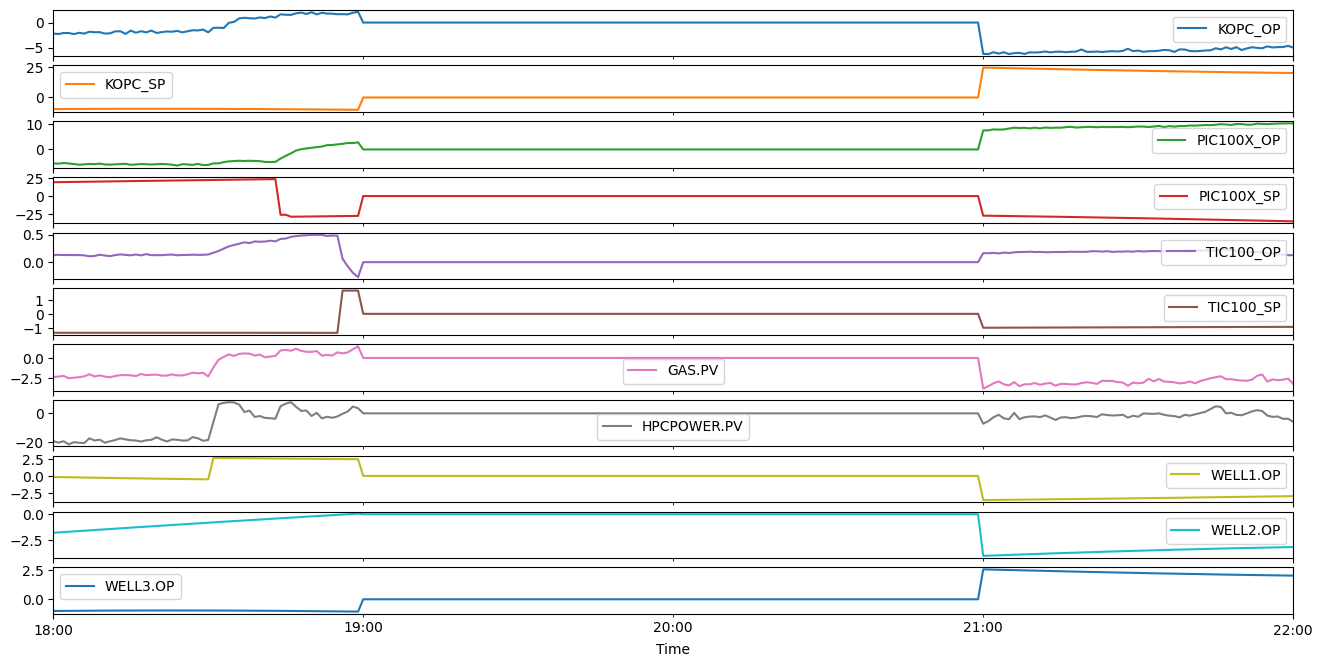

In [28]:
idinput[tags_to_plot].loc['07-18-2016 18:00':'07-18-2016 22:00'].plot(subplots=True)

In [13]:
# Resample datadet
idinput_resampled = idinput.resample(str(resampling)+'min').mean()
tsample = pd.Timedelta(idinput_resampled.index[1] - idinput_resampled.index[0]).total_seconds() # data sampling time
# Convert dataframe to numpy array in the shape requied for SIPPY
u = idinput_resampled[inputs].to_numpy().T
y = idinput_resampled[outputs].to_numpy().T
print('Output shape:', y.shape)
print('Input shape:',u.shape)

Output shape: (5, 38011)
Input shape: (6, 38011)


In [14]:
print(len(idinput_resampled.index))
print(len(idinput.index))

38011
38011


In [15]:
id_result = system_identification(
    y=y,
    u=u,
    id_method=id_method,
    tsample= tsample,
    SS_fixed_order=fix_ordr,
    SS_orders=ss_orders,
    SS_threshold=SS_threshold,
    IC=IC,
    SS_f=TH,
    SS_D_required=req_D,
    SS_A_stability=force_A_stable
    )

The suggested order is: n= 11


In [16]:
firmodel = get_fir_coef(model=id_result.G, inds=inputs, deps=outputs, sampling=60, tss=tss)
step_response = get_step_response(firmodel)
t = np.arange(0, tss)

## DMC3 reference model
![model](upstream_hp.jpg)

In [33]:
input_tag = 'WELL1.OP'
output_tag = 'PIC100X_OP'

In [34]:
imp_ij = firmodel[output_tag][input_tag]
stp_ij = step_response[output_tag][input_tag]
u = idinput[input_tag]
y = idinput[output_tag]

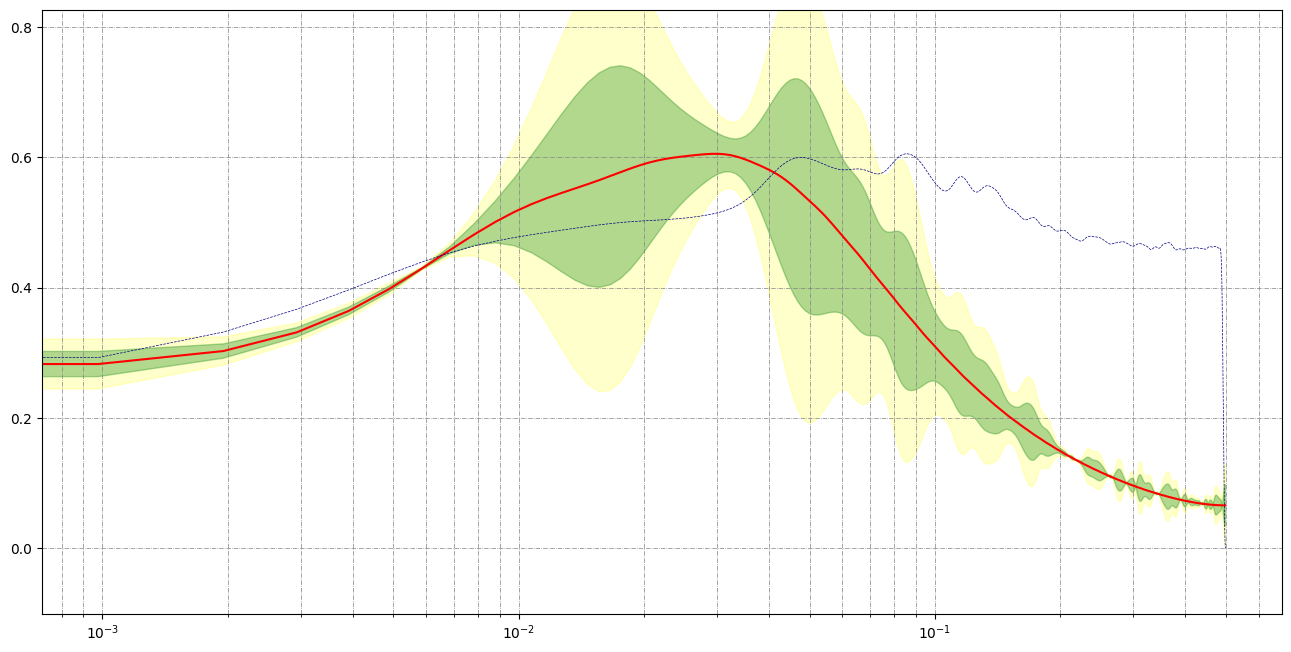

In [35]:
freqs, mag, ci95, ci68, snr = get_model_uncertainty(u, y, imp_ij)
snr_scaled = np.interp(snr, (snr.min(), snr.max()), (0, max(mag)))
plt.figure(2)
axes = plt.gca()
ylim = max(mag)*1.2
axes.set_ylim([-0.1,ylim+0.1])
axes.plot(freqs, mag, color='red')
axes.plot(freqs, snr_scaled, color='navy',linestyle="--", linewidth=0.5)
axes.fill_between(freqs, (mag-ci95), (mag+ci95), color='yellow', alpha=0.2)
axes.fill_between(freqs, (mag-ci68), (mag+ci68), color='green', alpha=0.3)
axes.semilogx()
axes.grid(True, which="both",color='gray', linestyle="-.", linewidth=0.5)

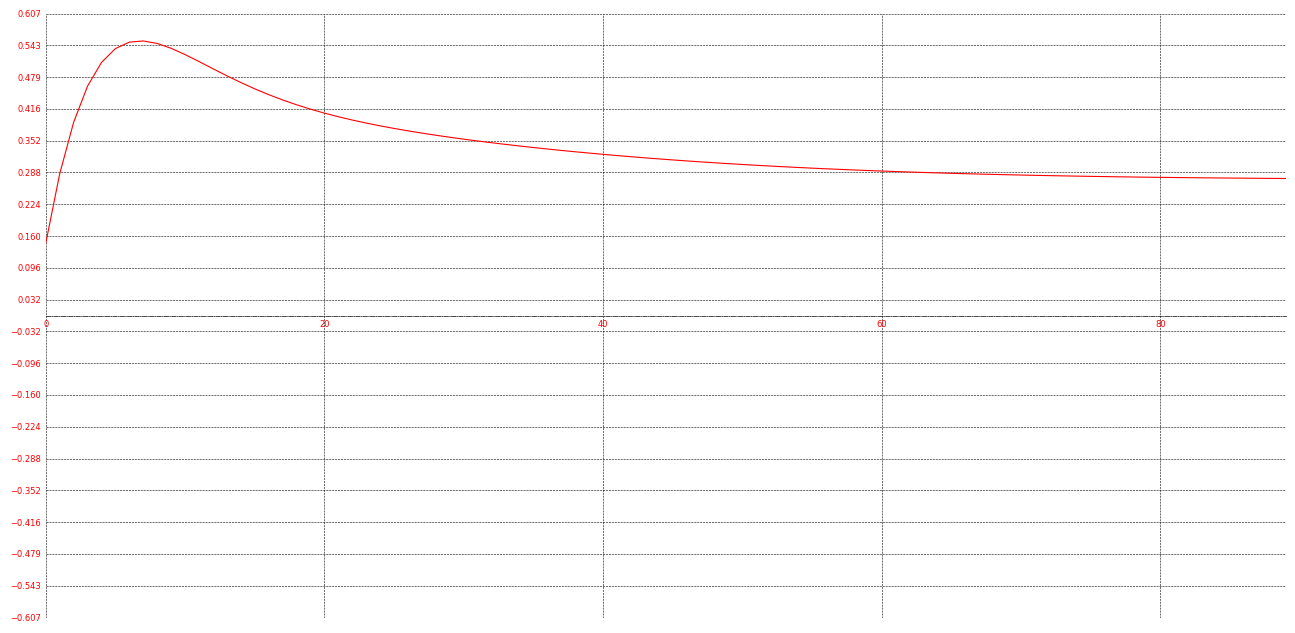

In [36]:
plt.figure(1)
axes = plt.gca()
ylim = max(abs(stp_ij))*1.1
axes.set_ylim([-ylim,ylim])
colr = "red"
axes.grid(color='k', linestyle='--', linewidth=0.4)
axes.spines.bottom.set_position('zero')
axes.spines.bottom.set_linestyle('-.')
axes.spines.bottom.set_linewidth(0.5)
axes.spines[['left', 'top', 'right']].set_visible(False)
axes.xaxis.set_ticks_position('bottom')
axes.yaxis.set_ticks_position('left')
plt.xticks(np.arange(0, tss+2, 20.0))
plt.yticks(np.linspace(-ylim, ylim, 20))
axes.tick_params(axis='x', colors=colr,size=0,labelsize=6)
axes.tick_params(axis='y', colors=colr,size=0,labelsize=6)
axes.margins(x=0, y=0)
plt.plot(t, stp_ij, color=colr, linewidth=0.8)

In [23]:
deadtime = get_deadtime(stp_ij)

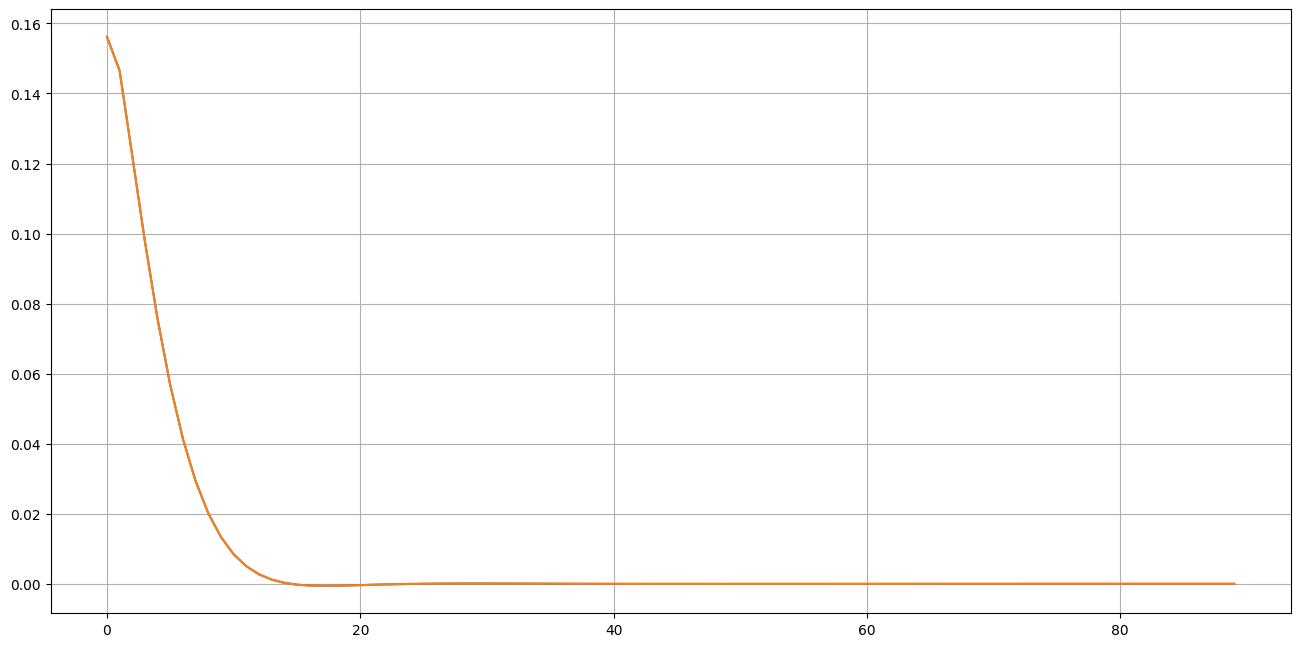

In [24]:
imp_ij_shift = imp_ij.copy()
if deadtime > 1:
    imp_ij_shift[:deadtime] = 0
plt.plot(imp_ij)
plt.plot(imp_ij_shift)
plt.grid()

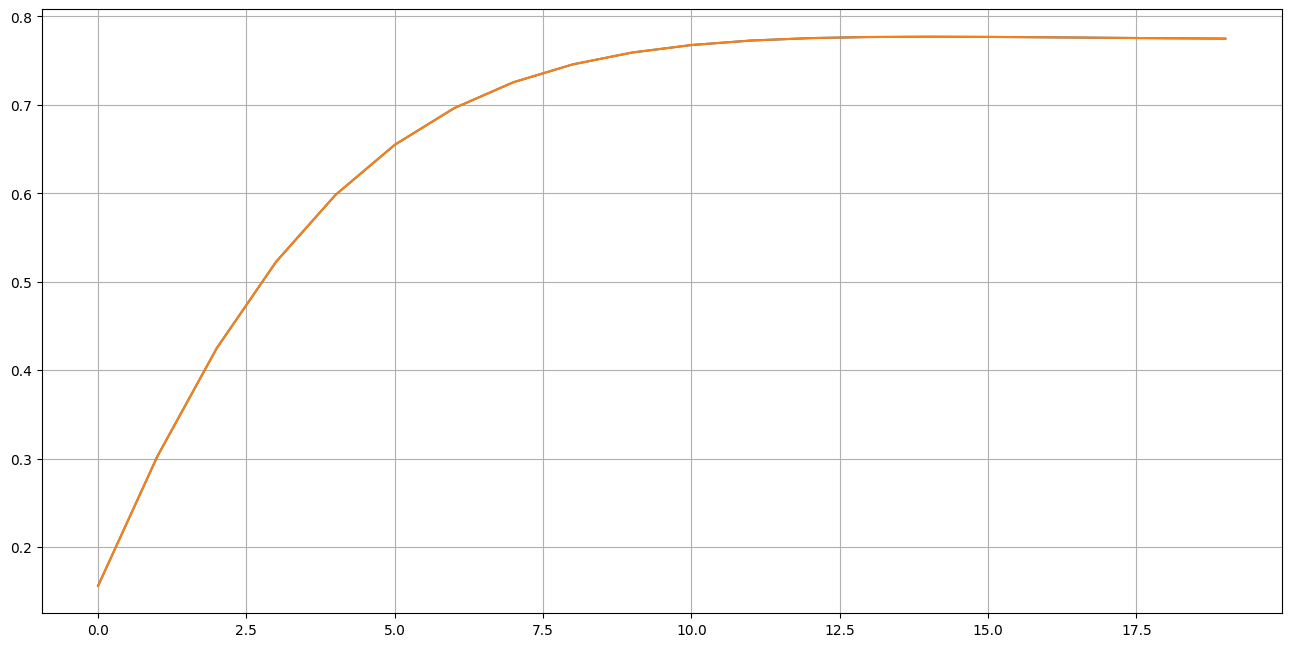

In [25]:
shift_step = np.cumsum(imp_ij_shift)
plt.plot(stp_ij[:20])
plt.plot(shift_step[:20])
plt.grid()

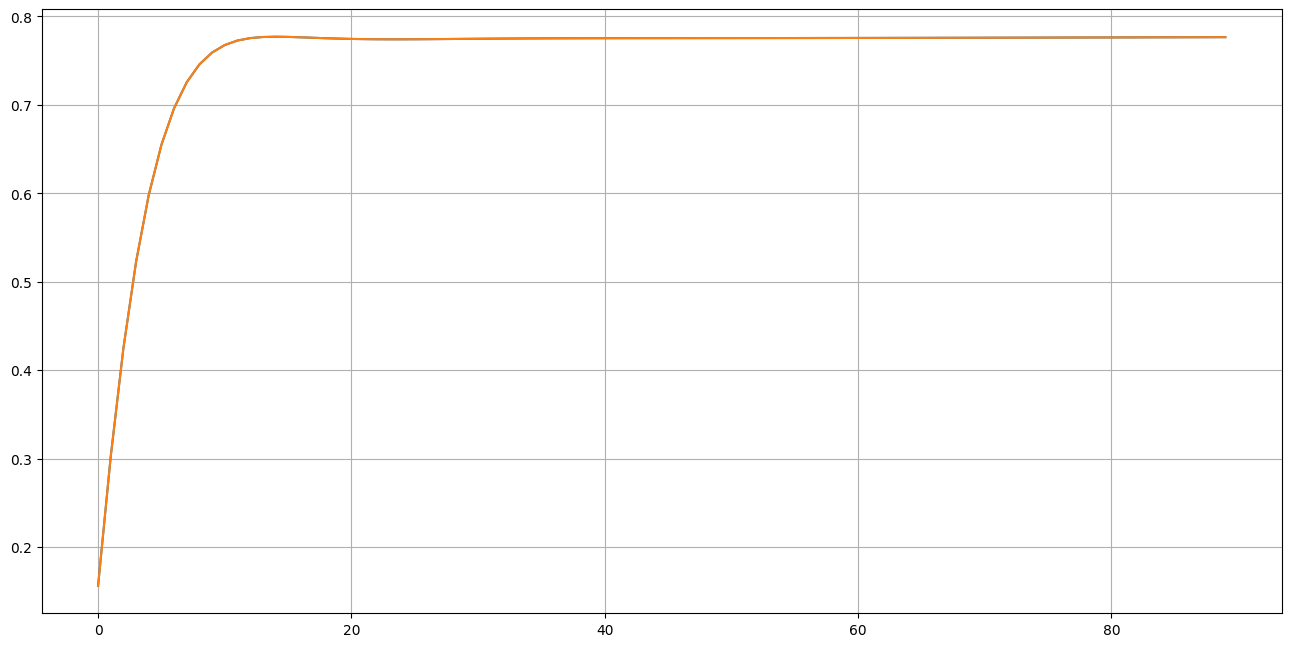

In [26]:
shift_step = np.cumsum(imp_ij_shift)
plt.plot(stp_ij)
plt.plot(shift_step)
plt.grid()